# Mineração de Dados - 2026/05/22

## Nomes dos Cientistas de Dados

Luis Henrique da Silva

Tarsis Mikael Ventura Dumas de Lima

Instalar biblioteca

In [38]:
!pip install ipeadatapy pandas scikit-learn mlxtend

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Importar bibliotecas

In [39]:
import ipeadatapy as ipea
import pandas as pd
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

Criando a base de dados sintética e salvando como CSV

In [40]:
print("Gerando base de dados sintética de Logística...")
np.random.seed(42)

Gerando base de dados sintética de Logística...


Simulando 300 entregas com Distância (km) e Peso da Carga (kg)

In [41]:
distancia = np.concatenate([np.random.normal(20, 5, 100), np.random.normal(80, 15, 100), np.random.normal(150, 20, 100)])
peso = np.concatenate([np.random.normal(5, 2, 100), np.random.normal(50, 10, 100), np.random.normal(15, 5, 100)])

df_sintetico = pd.DataFrame({'Distancia_km': distancia, 'Peso_kg': peso})
# Salvando o arquivo CSV na mesma pasta do seu projeto
df_sintetico.to_csv('dados_logistica.csv', index=False)
print("Arquivo 'dados_logistica.csv' criado com sucesso!\n")

Arquivo 'dados_logistica.csv' criado com sucesso!



Lê a base de dados

In [42]:
print("1. Lendo a base de dados...")
df = pd.read_csv('dados_logistica.csv')

1. Lendo a base de dados...


Faz o pré-processamento

In [43]:
print("2. Realizando o pré-processamento (Padronização)...")
# O StandardScaler é essencial no K-Means para que a Distância e o Peso tenham o mesmo peso no cálculo
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(df)

2. Realizando o pré-processamento (Padronização)...


Aplica o KMeans e usa o Coeficiente de Silhueta para achar o K ideal

In [44]:
print("3 e 4. Calculando o KMeans e a Silhueta para descobrir o número ideal de grupos...")

melhor_k = 2
melhor_silhueta = -1
valores_silhueta = []
range_k = range(2, 8)

for k in range_k:
    # Aplica o KMeans
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_teste.fit_predict(X_padronizado)
    
    score = silhouette_score(X_padronizado, labels)
    valores_silhueta.append(score)
    
    print(f"   - Para k={k}, o Coeficiente de Silhueta é: {score:.4f}")
    
    if score > melhor_silhueta:
        melhor_silhueta = score
        melhor_k = k

3 e 4. Calculando o KMeans e a Silhueta para descobrir o número ideal de grupos...
   - Para k=2, o Coeficiente de Silhueta é: 0.5833
   - Para k=3, o Coeficiente de Silhueta é: 0.7790
   - Para k=4, o Coeficiente de Silhueta é: 0.6866
   - Para k=5, o Coeficiente de Silhueta é: 0.5841
   - Para k=6, o Coeficiente de Silhueta é: 0.5746
   - Para k=7, o Coeficiente de Silhueta é: 0.5475


Apresenta o resultado do coeficiente de silhueta e agrupamento

In [45]:
print(f"\n5. RESULTADO FINAL:")
print(f"O número ideal de grupos é K = {melhor_k}, com Coeficiente de Silhueta de {melhor_silhueta:.4f}")


5. RESULTADO FINAL:
O número ideal de grupos é K = 3, com Coeficiente de Silhueta de 0.7790


Treinando o modelo final com o melhor K descoberto matematicamente

In [46]:
kmeans_final = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)
df['Grupo'] = kmeans_final.fit_predict(X_padronizado)

VISUALIZAÇÃO DOS RESULTADOS (Para o print da atividade)

In [47]:
plt.figure(figsize=(14, 6))
plt.style.use('dark_background')

<Figure size 1400x600 with 0 Axes>

Gráfico 1: A curva do Coeficiente de Silhueta

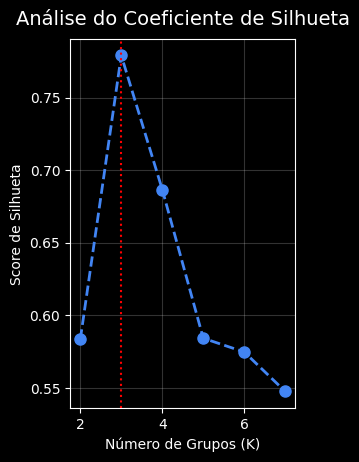

In [48]:
plt.subplot(1, 2, 1)
plt.plot(range_k, valores_silhueta, marker='o', linestyle='--', color='#4285F4', linewidth=2, markersize=8)
plt.axvline(x=melhor_k, color='red', linestyle=':')
plt.title('Análise do Coeficiente de Silhueta', fontsize=14, pad=10)
plt.xlabel('Número de Grupos (K)')
plt.ylabel('Score de Silhueta')
plt.grid(True, alpha=0.2)

Gráfico 2: O Agrupamento Final (Scatter Plot)

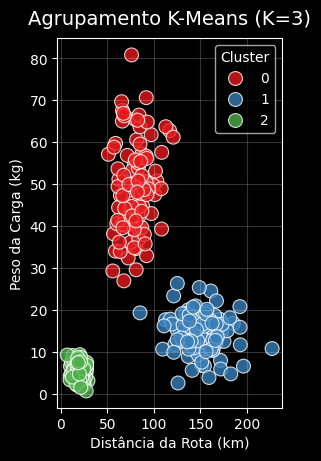

In [49]:
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Distancia_km', y='Peso_kg', hue='Grupo', palette='Set1', s=100, alpha=0.8, edgecolor='white')
plt.title(f'Agrupamento K-Means (K={melhor_k})', fontsize=14, pad=10)
plt.xlabel('Distância da Rota (km)')
plt.ylabel('Peso da Carga (kg)')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.2)

Gerar o grafico

In [50]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>